C:\Users\knut1\AppData\Local\Temp\ipykernel_12488\2344414833.py:34: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(to_uint8(img01), mode="RGB").save(path)


Saved outputs to: C:\Users\knut1\Documents\Computer_Vision_Exercises\Chapter_3_Image_Processing\outputs_ex3_6


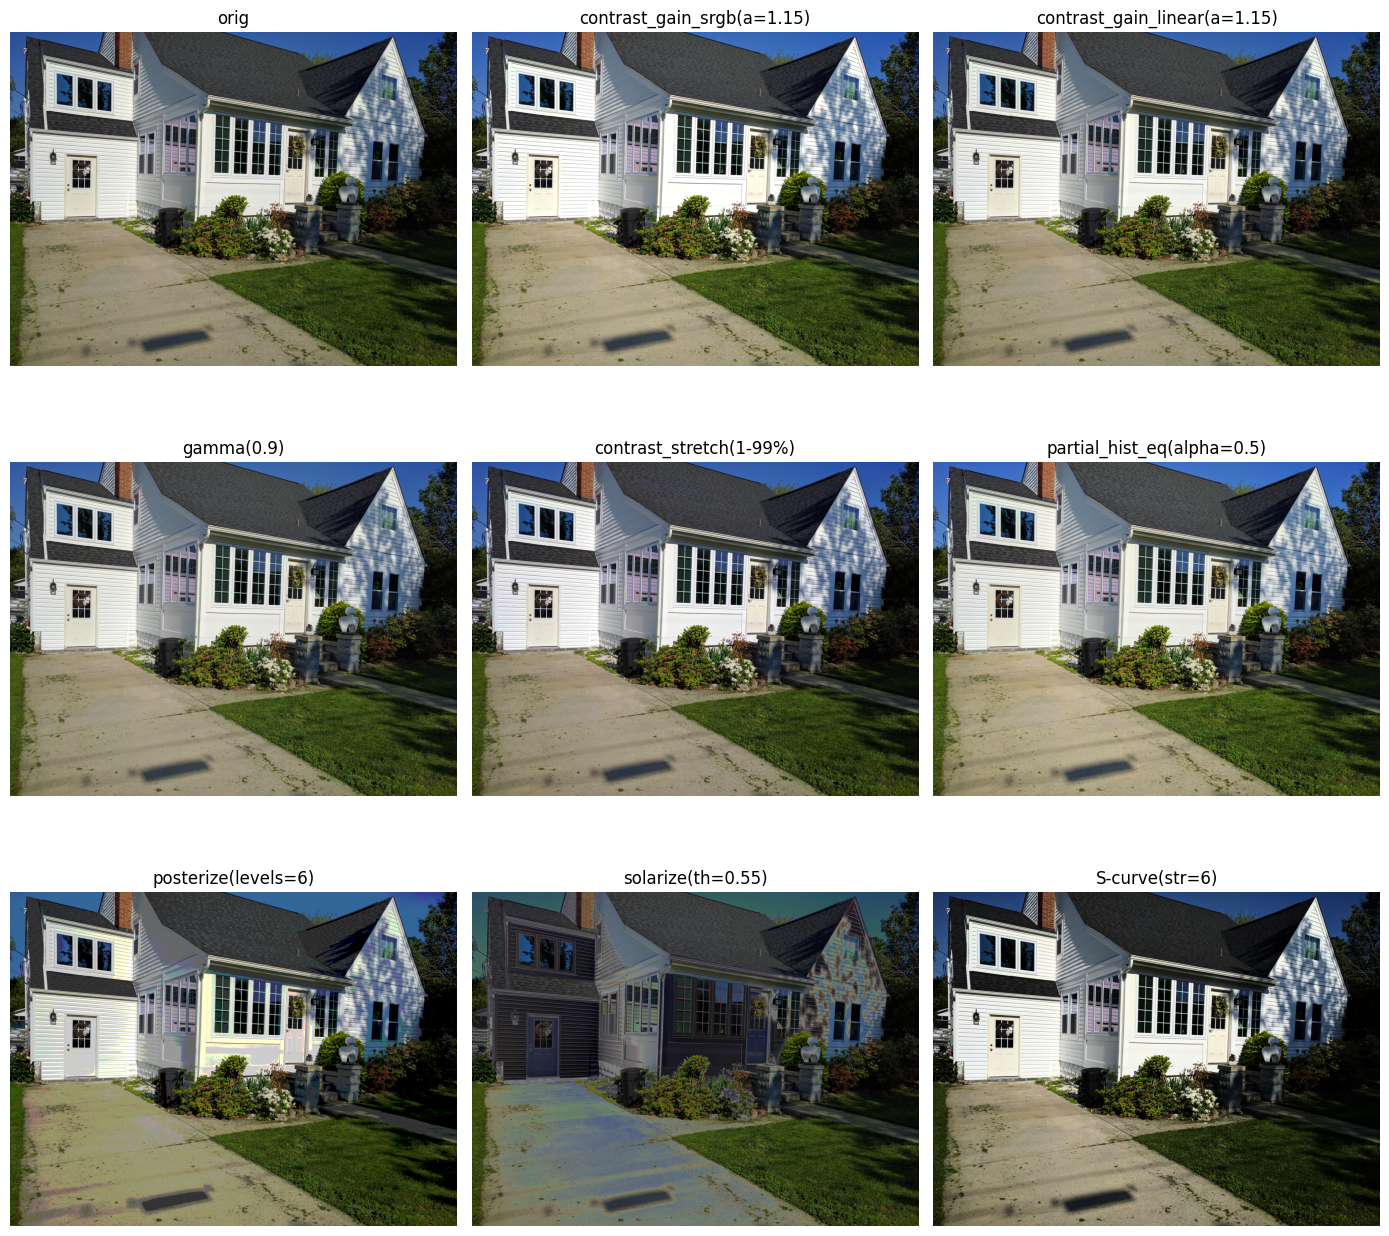

In [1]:
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
img_path = Path("..") / "Files" / "Random_Images" / "houses_3.jpg"
out_dir = Path("outputs_ex3_6")
out_dir.mkdir(exist_ok=True)

# -----------------------------
# Helpers: sRGB <-> linear
# (useful because many "physically meaningful" ops should be in linear light)
# -----------------------------
def srgb_to_linear(u):
    u = np.clip(u, 0.0, 1.0)
    a = 0.055
    return np.where(u <= 0.04045, u / 12.92, ((u + a) / (1 + a)) ** 2.4)

def linear_to_srgb(u):
    u = np.clip(u, 0.0, 1.0)
    a = 0.055
    return np.where(u <= 0.0031308, 12.92 * u, (1 + a) * (u ** (1/2.4)) - a)

def to_float01(pil_img):
    return np.asarray(pil_img).astype(np.float32) / 255.0

def to_uint8(img01):
    return (np.clip(img01, 0.0, 1.0) * 255.0 + 0.5).astype(np.uint8)

def save_rgb(path, img01):
    Image.fromarray(to_uint8(img01), mode="RGB").save(path)

# Luminance (simple Rec.709-ish weights; good enough for this exercise)
def luminance(rgb):
    r, g, b = rgb[...,0], rgb[...,1], rgb[...,2]
    return 0.2126*r + 0.7152*g + 0.0722*b

# Preserve chroma by scaling RGB using Y_new / Y_old (avoid hue shifts)
# (text discusses working with luminance + chromaticity / ratios) :contentReference[oaicite:1]{index=1}
def replace_luminance(rgb, Y_new, eps=1e-6):
    Y_old = luminance(rgb)
    s = Y_new / (Y_old + eps)
    return np.clip(rgb * s[...,None], 0.0, 1.0)

# -----------------------------
# Effects
# -----------------------------
# 1) Brightness/Contrast: g = a*f + b (point operator) :contentReference[oaicite:2]{index=2}
def gain_bias(img, a=1.1, b=0.0):
    return np.clip(a * img + b, 0.0, 1.0)

# 2) Gamma adjustment (tone curve). Gamma shows up a lot in camera/display pipelines. :contentReference[oaicite:3]{index=3}
def gamma_adjust(img, gamma=0.9):
    # gamma < 1 brightens midtones, gamma > 1 darkens midtones
    return np.clip(img ** gamma, 0.0, 1.0)

# 3) Contrast stretch using percentiles (good “auto-contrast”)
def contrast_stretch(img, lo=1, hi=99):
    out = img.copy()
    for c in range(3):
        p_lo = np.percentile(out[...,c], lo)
        p_hi = np.percentile(out[...,c], hi)
        out[...,c] = (out[...,c] - p_lo) / (p_hi - p_lo + 1e-8)
    return np.clip(out, 0.0, 1.0)

# 4) Histogram equalization on luminance (global). Can look “flat/muddy” sometimes. :contentReference[oaicite:4]{index=4}
def hist_equalize_luminance(rgb):
    Y = luminance(rgb)
    y8 = np.clip((Y * 255.0).astype(np.uint8), 0, 255)
    hist = np.bincount(y8.ravel(), minlength=256)
    cdf = np.cumsum(hist).astype(np.float32)
    cdf = (cdf - cdf.min()) / (cdf.max() - cdf.min() + 1e-8)
    Yeq = cdf[y8]
    return replace_luminance(rgb, Yeq)

# 5) Partial histogram equalization (blend equalized with identity) :contentReference[oaicite:5]{index=5}
def partial_hist_equalize_luminance(rgb, alpha=0.5):
    Y = luminance(rgb)
    rgb_eq = hist_equalize_luminance(rgb)
    Yeq = luminance(rgb_eq)
    Ymix = alpha * Yeq + (1 - alpha) * Y
    return replace_luminance(rgb, Ymix)

# 6) Posterize / Quantization (solarization mentioned as “quantization” in the exercise list)
def posterize(img, levels=6):
    # levels: number of bins per channel (>=2)
    levels = int(levels)
    q = np.floor(img * (levels - 1) + 0.5) / (levels - 1)
    return np.clip(q, 0.0, 1.0)

# 7) Solarize (classic photo effect: invert above threshold)
def solarize(img, threshold=0.5):
    return np.where(img >= threshold, 1.0 - img, img)

# Extra (optional): "S-curve" contrast (often useful for photos)
def s_curve(img, strength=6.0):
    # apply to luminance only, then reinsert
    Y = luminance(img)
    # sigmoid centered at 0.5
    Y2 = 1.0 / (1.0 + np.exp(-strength * (Y - 0.5)))
    # rescale to [0,1] roughly
    Y2 = (Y2 - Y2.min()) / (Y2.max() - Y2.min() + 1e-8)
    return replace_luminance(img, Y2)

# -----------------------------
# Load image
# -----------------------------
im = Image.open(img_path).convert("RGB")
rgb_srgb = to_float01(im)

# Also make a linear-light version for “physical-ish” edits
rgb_lin = srgb_to_linear(rgb_srgb)

# -----------------------------
# Apply effects
# -----------------------------
results = {}

# Useful-ish corrections
results["orig"] = rgb_srgb
results["contrast_gain_srgb(a=1.15)"] = gain_bias(rgb_srgb, a=1.15, b=0.0)
results["contrast_gain_linear(a=1.15)"] = linear_to_srgb(gain_bias(rgb_lin, a=1.15, b=0.0))
results["gamma(0.9)"] = gamma_adjust(rgb_srgb, gamma=0.9)
results["contrast_stretch(1-99%)"] = contrast_stretch(rgb_srgb, lo=1, hi=99)
results["partial_hist_eq(alpha=0.5)"] = partial_hist_equalize_luminance(rgb_srgb, alpha=0.5)

# Creative / “weird”
results["posterize(levels=6)"] = posterize(rgb_srgb, levels=6)
results["solarize(th=0.55)"] = solarize(rgb_srgb, threshold=0.55)

# Nice-looking photo-ish effect
results["S-curve(str=6)"] = s_curve(rgb_srgb, strength=6.0)

# -----------------------------
# Save all outputs
# -----------------------------
for name, img in results.items():
    safe = name.replace(" ", "_").replace("(", "").replace(")", "").replace("=", "")
    save_rgb(out_dir / f"{safe}.png", img)

print("Saved outputs to:", out_dir.resolve())

# -----------------------------
# Show a grid
# -----------------------------
keys = list(results.keys())
n = len(keys)
cols = 3
rows = (n + cols - 1) // cols

plt.figure(figsize=(14, 4.5 * rows))
for i, k in enumerate(keys, start=1):
    plt.subplot(rows, cols, i)
    plt.imshow(results[k])
    plt.title(k)
    plt.axis("off")
plt.tight_layout()
plt.show()
